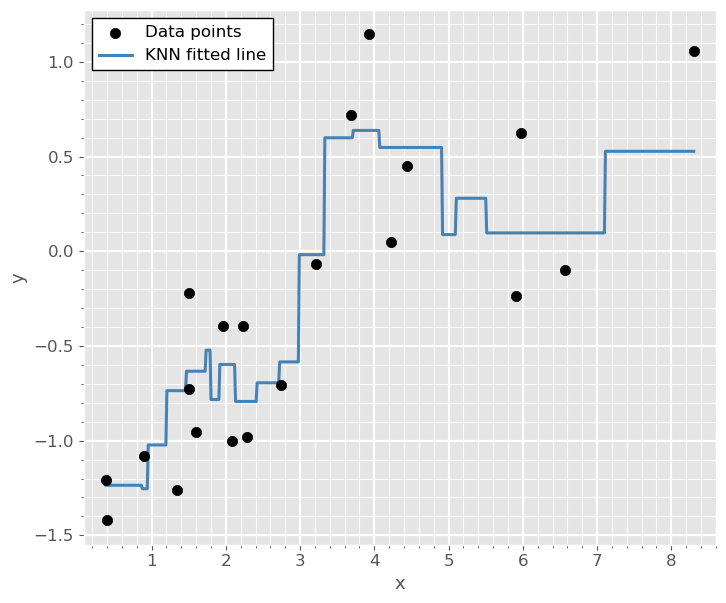

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor

# -----------------------------
# 1. Example data
# -----------------------------
np.random.seed(7)

x = np.sort(np.r_[
    np.random.uniform(0.2, 2.8, 12),
    np.random.uniform(3.0, 6.2, 7),
    np.random.uniform(6.5, 9.5, 2)
])

def true_signal(x):
    y = np.zeros_like(x)
    y[(x >= 0.0) & (x < 0.8)] = -1.45
    y[(x >= 0.8) & (x < 1.2)] = -1.10
    y[(x >= 1.2) & (x < 1.5)] = -0.95
    y[(x >= 1.5) & (x < 1.9)] = -0.55
    y[(x >= 1.9) & (x < 2.3)] = -0.35
    y[(x >= 2.3) & (x < 2.8)] = -0.60
    y[(x >= 2.8) & (x < 3.4)] = -0.20
    y[(x >= 3.4) & (x < 3.8)] = 0.55
    y[(x >= 3.8) & (x < 4.2)] = 0.95
    y[(x >= 4.2) & (x < 4.9)] = 0.55
    y[(x >= 4.9) & (x < 6.6)] = 0.25
    y[(x >= 6.6) & (x < 7.4)] = 0.85
    y[(x >= 7.4)] = 1.25
    return y

y = true_signal(x) + np.random.normal(0, 0.28, size=len(x))

# -----------------------------
# 2. Fit KNN regression
# -----------------------------
knn = KNeighborsRegressor(n_neighbors=3, weights="uniform")
knn.fit(x.reshape(-1, 1), y)

x_grid = np.linspace(x.min(), x.max(), 600)
y_knn = knn.predict(x_grid.reshape(-1, 1))

# -----------------------------
# 3. Plot
# -----------------------------
plt.style.use("ggplot")
fig, ax = plt.subplots(figsize=(7.36, 6.13))

ax.scatter(
    x, y,
    s=55,
    color="black",
    label="Data points",
    zorder=3
)

ax.plot(
    x_grid, y_knn,
    color="steelblue",
    linewidth=2.2,
    label="KNN fitted line",
    zorder=2
)

ax.set_xlim(x.min() - 0.3, x.max() + 0.3)
ax.set_xlabel("x", fontsize=13)
ax.set_ylabel("y", fontsize=13)
ax.tick_params(labelsize=12)

# 打开网格
ax.grid(True, which="major", color="white", linewidth=1.6)
ax.minorticks_on()
ax.grid(True, which="minor", color="white", linewidth=0.8, alpha=0.8)

# legend 加边框
leg = ax.legend(
    loc="best",
    fontsize=12,
    frameon=True,
    fancybox=False,
    framealpha=1.0
)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_facecolor("white")

plt.tight_layout()
plt.savefig("knn-reg.png", dpi=300, bbox_inches="tight")
plt.show()

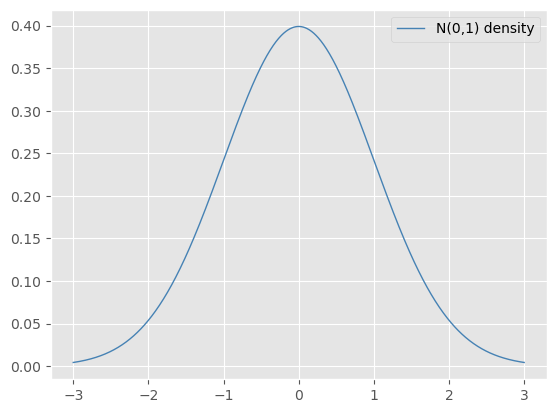

In [19]:
from scipy.stats import norm

x = np.linspace(-3,3,1000)
y = norm.pdf(x)

plt.plot(x,y,color = "steelblue", lw=1,label='N(0,1) density')
plt.legend()
plt.savefig("normal-density.png", dpi=300, bbox_inches="tight")
plt.show()

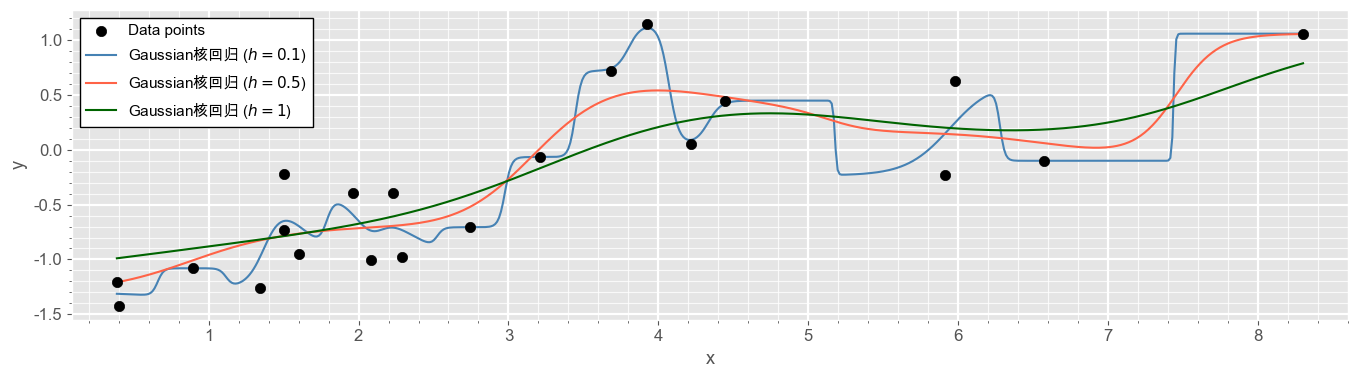

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS"]   # macOS 常见可用
plt.rcParams["axes.unicode_minus"] = False
# -----------------------------
# 1. Example data
# -----------------------------
np.random.seed(7)

x = np.sort(np.r_[
    np.random.uniform(0.2, 2.8, 12),
    np.random.uniform(3.0, 6.2, 7),
    np.random.uniform(6.5, 9.5, 2)
])

def true_signal(x):
    y = np.zeros_like(x)
    y[(x >= 0.0) & (x < 0.8)] = -1.45
    y[(x >= 0.8) & (x < 1.2)] = -1.10
    y[(x >= 1.2) & (x < 1.5)] = -0.95
    y[(x >= 1.5) & (x < 1.9)] = -0.55
    y[(x >= 1.9) & (x < 2.3)] = -0.35
    y[(x >= 2.3) & (x < 2.8)] = -0.60
    y[(x >= 2.8) & (x < 3.4)] = -0.20
    y[(x >= 3.4) & (x < 3.8)] = 0.55
    y[(x >= 3.8) & (x < 4.2)] = 0.95
    y[(x >= 4.2) & (x < 4.9)] = 0.55
    y[(x >= 4.9) & (x < 6.6)] = 0.25
    y[(x >= 6.6) & (x < 7.4)] = 0.85
    y[(x >= 7.4)] = 1.25
    return y

y = true_signal(x) + np.random.normal(0, 0.28, size=len(x))

# -----------------------------
# 2. Gaussian kernel regression
# -----------------------------
def gaussian_kernel(u):
    return np.exp(-0.5 * u**2) / np.sqrt(2 * np.pi)

def kernel_regression(x_train, y_train, x_eval, h):
    y_hat = np.zeros_like(x_eval, dtype=float)
    for j, x0 in enumerate(x_eval):
        weights = gaussian_kernel((x0 - x_train) / h)
        y_hat[j] = np.sum(weights * y_train) / np.sum(weights)
    return y_hat

x_grid = np.linspace(x.min(), x.max(), 600)

# 3 个窗口（bandwidth）
# bandwidths = [0.25, 0.6, 1.2]
bandwidths = [0.1, 0.5, 1]
colors = ["steelblue", "tomato", "darkgreen"]

y_kernel_list = [
    kernel_regression(x, y, x_grid, h)
    for h in bandwidths
]

# -----------------------------
# 3. Plot
# -----------------------------
plt.style.use("ggplot")
# fig, ax = plt.subplots(figsize=(7.36, 6.13))
fig, ax = plt.subplots(figsize=(13.68, 3.88))

ax.scatter(
    x, y,
    s=55,
    color="black",
    label="Data points",
    zorder=3
)

for h, color, y_hat in zip(bandwidths, colors, y_kernel_list):
    ax.plot(
        x_grid, y_hat,
        color=color,
        linewidth=1.5,
        label=fr"Gaussian核回归 ($h={h}$)",
        zorder=2
    )

ax.set_xlim(x.min() - 0.3, x.max() + 0.3)
ax.set_xlabel("x", fontsize=13)
ax.set_ylabel("y", fontsize=13)
ax.tick_params(labelsize=12)

# 网格
ax.grid(True, which="major", color="white", linewidth=1.6)
ax.minorticks_on()
ax.grid(True, which="minor", color="white", linewidth=0.8, alpha=0.8)

# legend
leg = ax.legend(
    loc="best",
    fontsize=11,
    frameon=True,
    fancybox=False,
    framealpha=1.0
)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_facecolor("white")

plt.tight_layout()
plt.savefig("kernel-reg.png", dpi=300, bbox_inches="tight")
plt.show()